In [18]:
import pandas as pd
import numpy as np
df = pd.read_csv('Phishing_URL_ds_imputed_train.csv')
df_test = pd.read_csv('Phishing_URL_ds_imputed_test.csv') # to apply any feature engineering on train and test separately

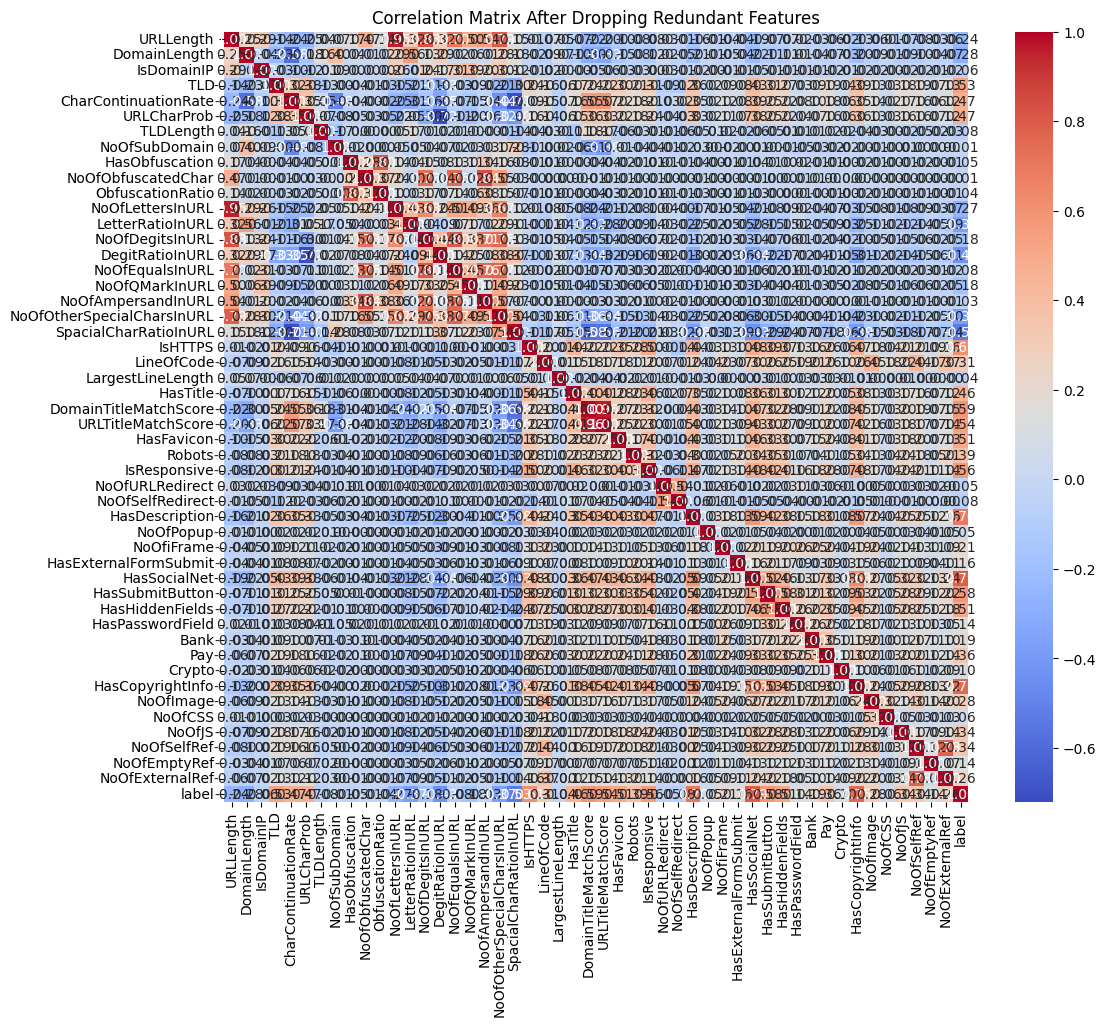

In [16]:
# I want to look at the correlation matrix again after feature engineering
import seaborn as sns
import matplotlib.pyplot as plt

df_for_heatmap = df.select_dtypes(include=[np.number])
corr_matrix = df_for_heatmap.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix After Dropping Redundant Features')
plt.show()

for URLSimilartyindex
it would use the Levenshtein Distance algorithm to compare the input URL against a cached list of the Top 500 targeted brands (PayPal, Gmail, Netflix, etc.).

we need to drop because, the feature URLSimilarityIndex is not just correlated with the label; it is practically the definition of the label for this dataset.

Feature Creation

I look into data and talk with gemini (https://gemini.google.com/share/e89cd886988c)
 I find it there could be a good feature creations to help the model understand and for better visulazation with t-SNE...

In [4]:
df.columns

Index(['URLLength', 'DomainLength', 'IsDomainIP', 'TLD',
       'CharContinuationRate', 'URLCharProb', 'TLDLength', 'NoOfSubDomain',
       'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio',
       'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL',
       'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL',
       'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL',
       'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength',
       'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon',
       'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect',
       'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit',
       'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields',
       'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo',
       'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef',
       'NoOfExternalRef', 'label'],
      dtype='object')

In [19]:
# 1. External Reference Ratio
df['External_Ref_Ratio'] = df['NoOfExternalRef'] / (df['NoOfSelfRef'] + df['NoOfEmptyRef'] + df['NoOfExternalRef'] + 1)

# 2. Dangerous Form Submission (Boolean interaction)
df['Unsafe_Form_Submit'] = ((df['HasPasswordField'] == 1) & (df['HasExternalFormSubmit'] == 1)).astype(int)

# 3. Sensitive Topic Aggregation
df['Sensitive_Keywords_Count'] = df['Bank'] + df['Pay'] + df['Crypto']

# 4. Domain Weight
df['Domain_Weight'] = df['DomainLength'] / df['URLLength']

# 1. External Reference Ratio
df_test['External_Ref_Ratio'] = df_test['NoOfExternalRef'] / (df_test['NoOfSelfRef'] + df_test['NoOfEmptyRef'] + df_test['NoOfExternalRef'] + 1)

# 2. Dangerous Form Submission (Boolean interaction)
df_test['Unsafe_Form_Submit'] = ((df_test['HasPasswordField'] == 1) & (df_test['HasExternalFormSubmit'] == 1)).astype(int)

# 3. Sensitive Topic Aggregation
df_test['Sensitive_Keywords_Count'] = df_test['Bank'] + df_test['Pay'] + df_test['Crypto']

# 4. Domain Weight
df_test['Domain_Weight'] = df_test['DomainLength'] / df_test['URLLength']

Scaling 
(I will apply robust scaling if there is so much outlier 
if there is moderaable I will oick standartscaling
the reason I choose these 2 is centring my variable at 0 so PCA will performs better )

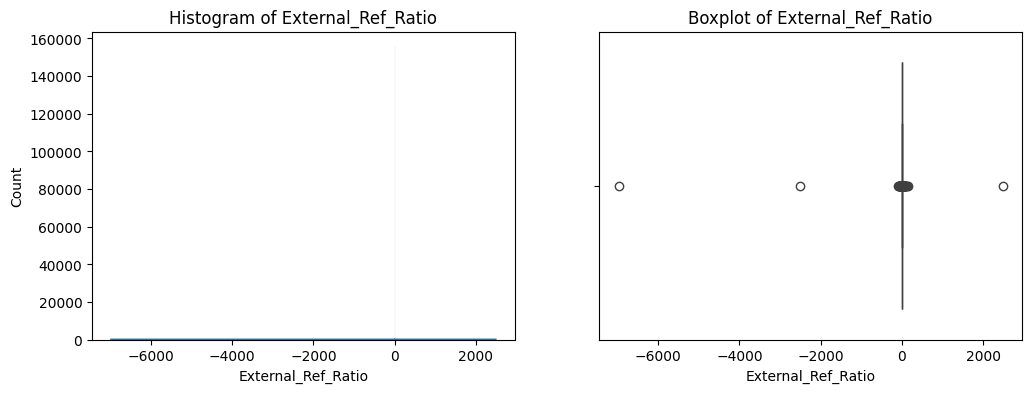

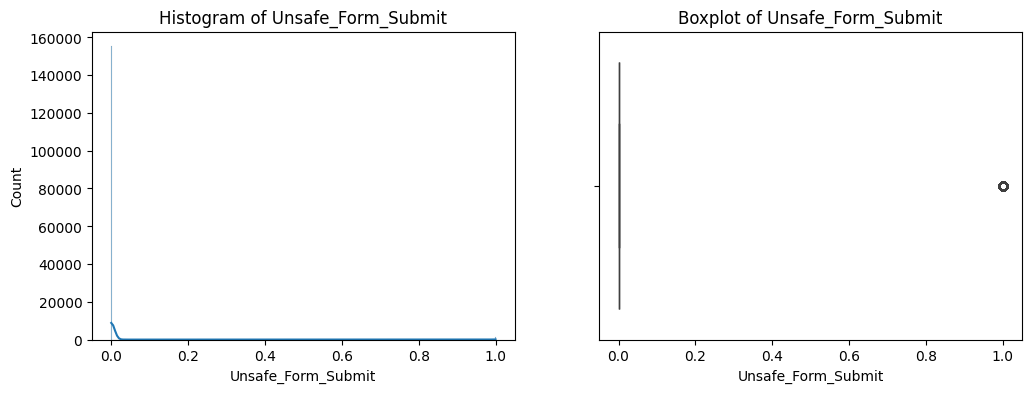

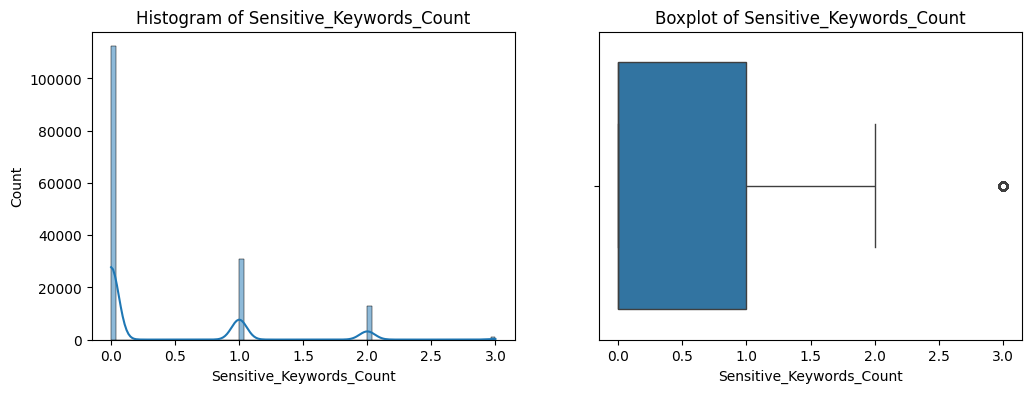

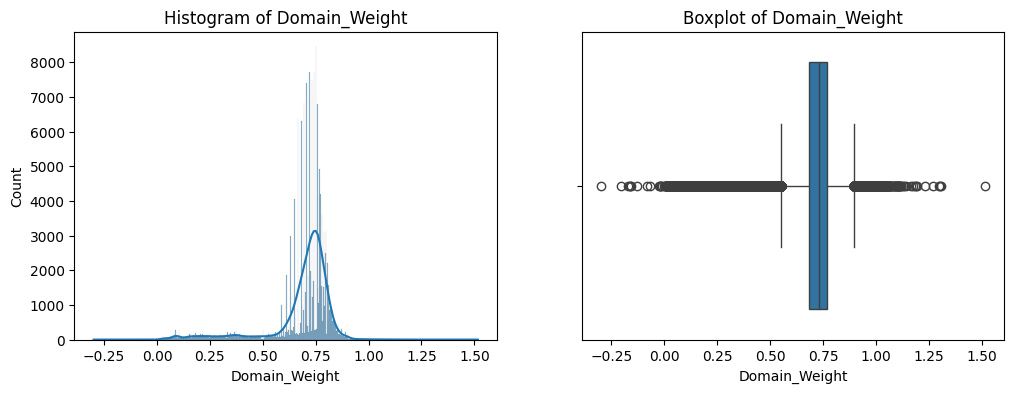

In [6]:
# I need to check their boxplot to see the distributions and apply scaling if needed
# I want to check individually also
for col in df[['External_Ref_Ratio','Unsafe_Form_Submit','Sensitive_Keywords_Count','Domain_Weight']]:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col], ax=axes[0], kde=True)
    sns.boxplot(x=df[col], ax=axes[1])
    axes[0].set_title(f'Histogram of {col}')
    axes[1].set_title(f'Boxplot of {col}')
    plt.show()

In [7]:
#check the Domain_Weight feature shapiro wilk test
from scipy.stats import shapiro
stat, p = shapiro(df['Domain_Weight'])
print(f'Shapiro-Wilk Test: Statistics={stat:.4f}, p-value={p:.4f}')

if p < 0.05:
    print("Domain_Weight feature is not normally distributed (reject H0)")
else:
    print("Domain_Weight feature is normally distributed (fail to reject H0)")

Shapiro-Wilk Test: Statistics=0.7239, p-value=0.0000
Domain_Weight feature is not normally distributed (reject H0)


/Users/akkus/Documents/GitHub/Phishing-URL--Website--Detection/.venv/lib/python3.14/site-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 156808.
  res = hypotest_fun_out(*samples, **kwds)


*Mixed Scaling Technique*:
we will apply standard scaling to binary features and others robust (they have a lots of outlier) gemini talk: https://gemini.google.com/share/83c294eaeeb7

In [8]:
df.describe()
for col in df.columns:
    print(f"{col}: min={df[col].min()}, max={df[col].max()}")

URLLength: min=13.0, max=5794.0
DomainLength: min=-5.393580628576592, max=110.0
IsDomainIP: min=0, max=1
TLD: min=0.0, max=1.0
CharContinuationRate: min=-0.0127130815674365, max=2.8486409116814917
URLCharProb: min=-0.0039878336446363, max=0.090823664
TLDLength: min=1.451902039554438, max=13.0
NoOfSubDomain: min=-0.6997229909506868, max=10.0
HasObfuscation: min=0, max=1
NoOfObfuscatedChar: min=-7.110487028949825, max=447.0
ObfuscationRatio: min=-0.0159402706726586, max=0.345
NoOfLettersInURL: min=-4.187253941649198, max=4992.0
LetterRatioInURL: min=-0.0011085981774099, max=1.8699771746920435
NoOfDegitsInURL: min=-10.105431977405408, max=2011.0
DegitRatioInURL: min=-0.1513128617038112, max=0.684
NoOfEqualsInURL: min=-1.7723692385015812, max=163.0
NoOfQMarkInURL: min=-0.9495221190639144, max=4.0
NoOfAmpersandInURL: min=-1.3356763313975146, max=149.0
NoOfOtherSpecialCharsInURL: min=-0.6882754124540327, max=445.0
SpacialCharRatioInURL: min=-1.9048849353304411, max=0.397
IsHTTPS: min=0, max=

In [20]:
#picking up most important features binaries from EDA and feature selection
X_train = df.drop(columns=['label'])
y_train = df['label']
X_test = df_test.drop(columns=['label'])
y_test = df_test['label']
#most important 4 binary features distribution by label
binary_cols = [
    'IsDomainIP', 'HasObfuscation', 'IsHTTPS', 'HasTitle', 'HasFavicon', 
    'Robots', 'IsResponsive', 'HasDescription', 'HasExternalFormSubmit', 
    'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 
    'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo','Unsafe_Form_Submit'
    ]
from sklearn.feature_selection import SelectKBest, chi2

# 1. IDENTIFY ALL BINARY COLUMNS
# We assume binary columns have exactly 2 unique values (0 and 1)
binary_cols = [col for col in X_train.columns if X_train[col].nunique() == 2]

print(f"Total Binary Features Detected: {len(binary_cols)}")
print(f"List: {binary_cols}")

# 2. SCORE THEM (Chi-Squared Test)
# Chi2 is the best statistical test for Binary Feature vs Binary Target
selector = SelectKBest(score_func=chi2, k=4)

# We fit ONLY on the binary columns of the training set
selector.fit(X_train[binary_cols], y_train)

# 3. GET THE WINNERS
# Get the boolean mask of the selected top 4
mask = selector.get_support()
# Filter the list of names using the mask
top_4_binary = [binary_cols[i] for i in range(len(binary_cols)) if mask[i]]

print("\n THE TOP 4 MOST IMPORTANT BINARY FEATURES:")
for feature in top_4_binary:
    print(f" - {feature}")

# 4. IDENTIFY THE LOSERS (To be dropped)
# These are binary columns that did NOT make the top 4
dropped_binary = [col for col in binary_cols if col not in top_4_binary]

# 5. EXECUTE THE DROP
# Remove the unimportant binary features from both Train and Test
X_train = X_train.drop(columns=dropped_binary)
X_test = X_test.drop(columns=dropped_binary)

print(f"\n Dropped {len(dropped_binary)} unimportant binary features.")
print(f"New Feature Count: {X_train.shape[1]}")
print("Your dataset now contains only the Top 4 binary features + all continuous features.")

Total Binary Features Detected: 18
List: ['IsDomainIP', 'HasObfuscation', 'IsHTTPS', 'HasTitle', 'HasFavicon', 'Robots', 'IsResponsive', 'HasDescription', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'Unsafe_Form_Submit']

 THE TOP 4 MOST IMPORTANT BINARY FEATURES:
 - HasDescription
 - HasSocialNet
 - HasSubmitButton
 - HasCopyrightInfo

 Dropped 14 unimportant binary features.
New Feature Count: 39
Your dataset now contains only the Top 4 binary features + all continuous features.


In [21]:
X_train.columns

Index(['URLLength', 'DomainLength', 'TLD', 'CharContinuationRate',
       'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'NoOfObfuscatedChar',
       'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL',
       'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL',
       'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL',
       'SpacialCharRatioInURL', 'LineOfCode', 'LargestLineLength',
       'DomainTitleMatchScore', 'URLTitleMatchScore', 'NoOfURLRedirect',
       'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame',
       'HasSocialNet', 'HasSubmitButton', 'HasCopyrightInfo', 'NoOfImage',
       'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef',
       'External_Ref_Ratio', 'Sensitive_Keywords_Count', 'Domain_Weight'],
      dtype='object')

In [22]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer, StandardScaler

# 1. DEFINE YOUR GROUPS
# We explicitly list the Top 4 Binary features we selected earlier
binary_cols = ['HasSubmitButton', 'HasSocialNet', 'HasCopyrightInfo', 'HasDescription']

# All other columns are Numeric (Integer counts + Continuous ratios)
# We filter X_train to get everything that is NOT in the binary list
numeric_cols = [col for col in X_train.columns if col not in binary_cols]

print(f"Binary Features ({len(binary_cols)}): {binary_cols}")
print(f"Numeric Features ({len(numeric_cols)}): {numeric_cols}")

# 2. CONSTRUCT THE TRANSFORMERS
# A. For Numeric: Yeo-Johnson acts as an "Automatic Transformation Machine"
# standardize=True means it performs (Transformation -> StandardScaler) in one step.
numeric_transformer = PowerTransformer(method='yeo-johnson', standardize=True)

# B. For Binary: Just Scaling
binary_transformer = StandardScaler()

# 3. COMBINE INTO ONE PROCESSOR
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('bin', binary_transformer, binary_cols)
    ],
    # This setting helps keep column names clean in newer sklearn versions
    verbose_feature_names_out=False 
)

# 4. EXECUTE (Fit on Train, Transform Test)
print("\nApplying PowerTransformer and Scaling...")

# Fit and Transform Train
X_train_matrix = preprocessor.fit_transform(X_train)

# Transform Test (Do NOT fit again!)
X_test_matrix = preprocessor.transform(X_test)

# 5. CONVERT BACK TO DATAFRAME (Critical for visualization)
# The ColumnTransformer reorders columns: Numeric first, then Binary
all_cols = numeric_cols + binary_cols

X_train_final = pd.DataFrame(X_train_matrix, columns=all_cols, index=X_train.index)
X_test_final = pd.DataFrame(X_test_matrix, columns=all_cols, index=X_test.index)

print("✅ Success! Data is transformed, scaled, and ready for PCA/t-SNE.")
print(f"Output Shape: {X_train_final.shape}")

Binary Features (4): ['HasSubmitButton', 'HasSocialNet', 'HasCopyrightInfo', 'HasDescription']
Numeric Features (35): ['URLLength', 'DomainLength', 'TLD', 'CharContinuationRate', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'LineOfCode', 'LargestLineLength', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'NoOfPopup', 'NoOfiFrame', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'External_Ref_Ratio', 'Sensitive_Keywords_Count', 'Domain_Weight']

Applying PowerTransformer and Scaling...
✅ Success! Data is transformed, scaled, and ready for PCA/t-SNE.
Output Shape: (156808, 39)


In [24]:
import pandas as pd

# Sonuçları tutacak bir liste
skew_results = []

# Sadece Numeric (PowerTransformer uygulanan) sütunları kontrol ediyoruz
# Binary sütunlarda skewness düzeltmesi yapmadık (sadece scale ettik), o yüzden onları atlıyoruz.
for col in numeric_cols:
    # 1. Eski Skewness (X_train ham veri)
    skew_before = X_train[col].skew()
    
    # 2. Yeni Skewness (X_train_final dönüştürülmüş veri)
    skew_after = X_train_final[col].skew()
    
    # 3. Durum Değerlendirmesi
    # Mutlak değerce 0'a ne kadar yaklaştı?
    is_improved = abs(skew_after) < abs(skew_before)
    
    skew_results.append({
        'Feature': col,
        'Skew (Before)': round(skew_before, 4),
        'Skew (After)': round(skew_after, 4),
        'Improved?': "✅ YES" if is_improved else "➖ NO",
        'Status': 'Normal' if abs(skew_after) < 0.5 else 'Still Skewed'
    })

# DataFrame'e çevirip tablo olarak gösterelim
df_verification = pd.DataFrame(skew_results)

# En bozuk (Skewed) olanlardan başlayarak sıralayalım ki etkiyi görelim
df_verification = df_verification.sort_values(by='Skew (Before)', key=abs, ascending=False)

print("--- POWER TRANSFORMER ETKİ ANALİZİ ---")
print(df_verification.to_string()) # to_string() tüm satırları gösterir

--- POWER TRANSFORMER ETKİ ANALİZİ ---
                       Feature  Skew (Before)  Skew (After) Improved?        Status
27                     NoOfCSS       376.0003       64.8743     ✅ YES  Still Skewed
32          External_Ref_Ratio      -280.2564       53.5699     ✅ YES  Still Skewed
7           NoOfObfuscatedChar       206.9258      -36.9713     ✅ YES  Still Skewed
28                      NoOfJS       156.1992       -0.1880     ✅ YES        Normal
15          NoOfAmpersandInURL       116.5491      -16.9336     ✅ YES  Still Skewed
25                  NoOfiFrame       113.9278       -0.5657     ✅ YES  Still Skewed
13             NoOfEqualsInURL       110.1198      -29.7977     ✅ YES  Still Skewed
11             NoOfDegitsInURL        97.5269      -18.2397     ✅ YES  Still Skewed
24                   NoOfPopup        84.5432       -7.3391     ✅ YES  Still Skewed
31             NoOfExternalRef        74.3701       -2.7984     ✅ YES  Still Skewed
29                 NoOfSelfRef       

In [26]:
#combineing X_train_final and y_train to a single dataframe for saving and X_test_final and y_test
# to a single dataframe for saving
train_final = pd.concat([X_train_final, y_train.reset_index(drop=True)], axis=1)
test_final = pd.concat([X_test_final, y_test.reset_index(drop=True)], axis=1)

In [27]:
train_final.to_csv('Phishing_URL_ds_feature_engineered_train.csv', index=False)
test_final.to_csv('Phishing_URL_ds_feature_engineered_test.csv', index=False)